In [1]:
%matplotlib inline
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# path to saccade predictions 

datapathInfer = '/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/data4UnEye_merged/4Inference'
data_dir = os.path.join(datapathInfer, "model_outputs")
output_folder = data_dir

loadLog = True

In [2]:
# load data

os.chdir(data_dir)

d = np.load("uneye_inference_outputs.npz", allow_pickle=True)
Prediction2 = d["Prediction2"]
Probability2 = d["Probability2"]
fs = int(d["fs"])

# --------------------------------------------------------------------------------------------
# Load data segments used for saccade inference + their metadata (all sessions saved together)
# --------------------------------------------------------------------------------------------

infer_x_path = os.path.join(datapathInfer, "infer_x.csv")
infer_y_path = os.path.join(datapathInfer, "infer_y.csv")
infer_meta_path = os.path.join(datapathInfer, "infer_metadata.csv")
infer_sessinfo_path  =  os.path.join(datapathInfer, "infer_session_info.csv")

infer_x_all = np.loadtxt(infer_x_path, delimiter=",")  # shape: (n_rows, win)
infer_y_all = np.loadtxt(infer_y_path, delimiter=",")  # shape: (n_rows, win)
infer_meta = pd.read_csv(infer_meta_path)
infer_sessinfo = pd.read_csv(infer_sessinfo_path) # list of analyzed sessions, num. of dropped frames/secodns, segment lengths, num. of cut segments

# Sanity checks
assert infer_x_all.shape == infer_y_all.shape, "infer_x and infer_y must have same shape"
assert len(infer_meta) == infer_x_all.shape[0], "metadata rows must match infer arrays rows"

win = infer_x_all.shape[1]  # window length in SAMPLES (e.g., 1500)

# load the indeces of NaNs in the original signal
infer_nan_x_all = np.loadtxt(os.path.join(datapathInfer, "infer_nan_x.csv"), delimiter=",")
infer_nan_y_all = np.loadtxt(os.path.join(datapathInfer, "infer_nan_y.csv"), delimiter=",")

assert infer_nan_x_all.shape == infer_x_all.shape # infer_x should have same dim. as the infer_nan
assert infer_nan_y_all.shape == infer_y_all.shape


In [3]:
# Check names of analyzed sessions 
(infer_sessinfo)

# Note that session '20220825' does not contain the event marker 3042

,session,orig_len,kept_len,dropped_samples,dropped_seconds,win,hop,n_windows
0,20220825,1886923,1886500,423,0.846,1500,1000,1886
1,20230202,933296,932500,796,1.592,1500,1000,932
2,20230203,2037127,2036500,627,1.254,1500,1000,2036
3,20230206,3494038,3493500,538,1.076,1500,1000,3493
4,20230207,1913623,1913500,123,0.246,1500,1000,1913
5,20230208,3805757,3805500,257,0.514,1500,1000,3805
6,20230209,1903200,1902500,700,1.400,1500,1000,1902
7,20230213,2961531,2961500,31,0.062,1500,1000,2961
8,20230214,1834466,1833500,966,1.932,1500,1000,1833


Code to stich back together the segmented eye signals form each session into a continuous signal.
Nan's that were removed in the previous step (UnEye does not support nans) are put back, and it is 
important to make sure that the original raw timeseries has the same length as the stitched one.
Note that there are some plotting functions below that should be used for sanity check.


In [3]:
import numpy as np

def stitch_overlapped_windows_2d(windows: np.ndarray, starts: np.ndarray, win: int, allow_gaps: bool = False):
    windows = np.asarray(windows)
    starts = np.asarray(starts).astype(int)

    if windows.ndim != 2:
        raise ValueError(f"windows must be 2D (n_windows, win). Got {windows.shape}")
    if starts.ndim != 1 or starts.shape[0] != windows.shape[0]:
        raise ValueError("starts must be 1D and same length as windows")

    order = np.argsort(starts)
    starts = starts[order]
    windows = windows[order]

    out_len = int(starts[-1] + win) if len(starts) else 0
    out = np.full(out_len, np.nan, dtype=float)

    written_until = None
    for k, (s, w) in enumerate(zip(starts, windows)):
        e = s + win

        if k == 0:
            out[s:e] = w
            written_until = e
            continue

        if s < written_until:
            offset = written_until - s
            if offset < win:
                out[written_until:e] = w[offset:]
                written_until = e
        elif s == written_until:
            out[s:e] = w
            written_until = e
        else:
            if not allow_gaps:
                raise RuntimeError(f"Gap detected: next start {s} > written_until {written_until}")
            out[s:e] = w
            written_until = e

    return out


def append_dropped_nans(x_1d, n_drop: int):
    if n_drop <= 0:
        return x_1d
    return np.concatenate([x_1d, np.full(int(n_drop), np.nan, dtype=float)])


# ----------------------------
# Stitch per session
# ----------------------------
stitched = {}
drop_map = infer_sessinfo.set_index("session")["dropped_samples"].to_dict()

for session_name, df_sess in infer_meta.groupby("session", sort=False):
    rows = df_sess["row"].to_numpy(dtype=int)
    starts = df_sess["start_sample"].to_numpy(dtype=int)

    # per-session dropped tail (sliding windows)
    n_drop = int(drop_map.get(session_name, 0))

    # --- stitch x/y ---
    x_windows = infer_x_all[rows, :]
    y_windows = infer_y_all[rows, :]

    x_st = stitch_overlapped_windows_2d(x_windows, starts, win=win, allow_gaps=False)
    y_st = stitch_overlapped_windows_2d(y_windows, starts, win=win, allow_gaps=False)

    # --- stitch predictions (shape-safe) ---
    if Prediction2.ndim == 3:
        pred_windows = Prediction2[rows, 0, :]
    elif Prediction2.ndim == 2:
        pred_windows = Prediction2[rows, :]
    else:
        raise ValueError(f"Unexpected Prediction2 shape: {Prediction2.shape}")

    pred_st = stitch_overlapped_windows_2d(pred_windows, starts, win=win, allow_gaps=False)

    if Probability2.ndim == 3:
        prob_sacc_windows = Probability2[rows, 1, :]   # saccade prob
    elif Probability2.ndim == 2:
        prob_sacc_windows = Probability2[rows, :]      # already saccade prob
    else:
        raise ValueError(f"Unexpected Probability2 shape: {Probability2.shape}")

    prob_st = stitch_overlapped_windows_2d(prob_sacc_windows, starts, win=win, allow_gaps=False)

    # --- stitch NaN masks ---
    nanx_windows = infer_nan_x_all[rows, :]
    nany_windows = infer_nan_y_all[rows, :]

    nanx_st = stitch_overlapped_windows_2d(nanx_windows, starts, win=win, allow_gaps=False)
    nany_st = stitch_overlapped_windows_2d(nany_windows, starts, win=win, allow_gaps=False)

    # --- append dropped tail as NaNs (to ALL streams, including masks) ---
    x_st    = append_dropped_nans(x_st, n_drop)
    y_st    = append_dropped_nans(y_st, n_drop)
    pred_st = append_dropped_nans(pred_st, n_drop)
    prob_st = append_dropped_nans(prob_st, n_drop)

    nanx_st = append_dropped_nans(nanx_st, n_drop)
    nany_st = append_dropped_nans(nany_st, n_drop)
    
    # --- keep ORIGINAL stitched x/y (no NaNs reinserted yet) ---
    x_st_orig = x_st.copy()
    y_st_orig = y_st.copy()

    # --- reinsert NaNs at originally-missing samples ---
    nan_mask = (nanx_st > 0) | (nany_st > 0)

    x_st_nan = x_st.copy()
    y_st_nan = y_st.copy()
    pred_st_nan = pred_st.copy()
    prob_st_nan = prob_st.copy()

    x_st_nan[nan_mask] = np.nan
    y_st_nan[nan_mask] = np.nan
    pred_st_nan[nan_mask] = np.nan
    prob_st_nan[nan_mask] = np.nan

    # (optional) sanity checks
    assert len(x_st) == len(pred_st) == len(prob_st), "Length mismatch after stitching"
    assert nan_mask.shape[0] == x_st.shape[0], "NaN mask length mismatch"

    stitched[session_name] = {
        # original stitched signals (interpolated where NaNs used to be)
        "x_orig": x_st_orig,
        "y_orig": y_st_orig,

        # NaN-reinserted versions (recommended for downstream event analysis)
        "x_nan": x_st_nan,
        "y_nan": y_st_nan,

        # predictions (NaN-reinserted)
        "pred_nan": pred_st_nan,
        "prob_sacc_nan": prob_st_nan,

        # also keep the raw (non-NaN) predictions if you want
        "pred_orig": pred_st,
        "prob_sacc_orig": prob_st,

        "nan_mask": nan_mask,
        "dropped_samples": n_drop,
        "fs": fs,
    }

    print(f"{session_name}: stitched_len={len(pred_st)} samples ({len(pred_st)/fs:.1f}s), appended_drop={n_drop}")

stitched = {str(k).strip(): v for k, v in stitched.items()}


20220825: stitched_len=1886923 samples (3773.8s), appended_drop=423
20230202: stitched_len=933296 samples (1866.6s), appended_drop=796
20230203: stitched_len=2037127 samples (4074.3s), appended_drop=627
20230206: stitched_len=3494038 samples (6988.1s), appended_drop=538
20230207: stitched_len=1913623 samples (3827.2s), appended_drop=123
20230208: stitched_len=3805757 samples (7611.5s), appended_drop=257
20230209: stitched_len=1903200 samples (3806.4s), appended_drop=700
20230213: stitched_len=2961531 samples (5923.1s), appended_drop=31
20230214: stitched_len=1834466 samples (3668.9s), appended_drop=966


Save stitched data

In [5]:
save_path = os.path.join('/cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection', "stitched_sessions.npz")

np.savez(save_path, **{
    f"{sess}__{key}": val
    for sess, d in stitched.items()
    for key, val in d.items()
    if isinstance(val, np.ndarray)
}, sessions=list(stitched.keys()), fs=fs)

print(f"Saved to {save_path}")
print(f"Sessions: {list(stitched.keys())}")

Saved to /cs/projects/MWzeronoise/Analysis/4Shivangi/Results/saccade_detection/stitched_sessions.npz
Sessions: ['20220825', '20230202', '20230203', '20230206', '20230207', '20230208', '20230209', '20230213', '20230214']


## Plot saccades

Sanity-check plots\nChange `session` below to inspect different sessions. Shows:\n1. Full-session overview of eye position + saccade predictions\n2. Zoomed 10-second snippet so you can see individual saccades\n3. Saccade probability distribution

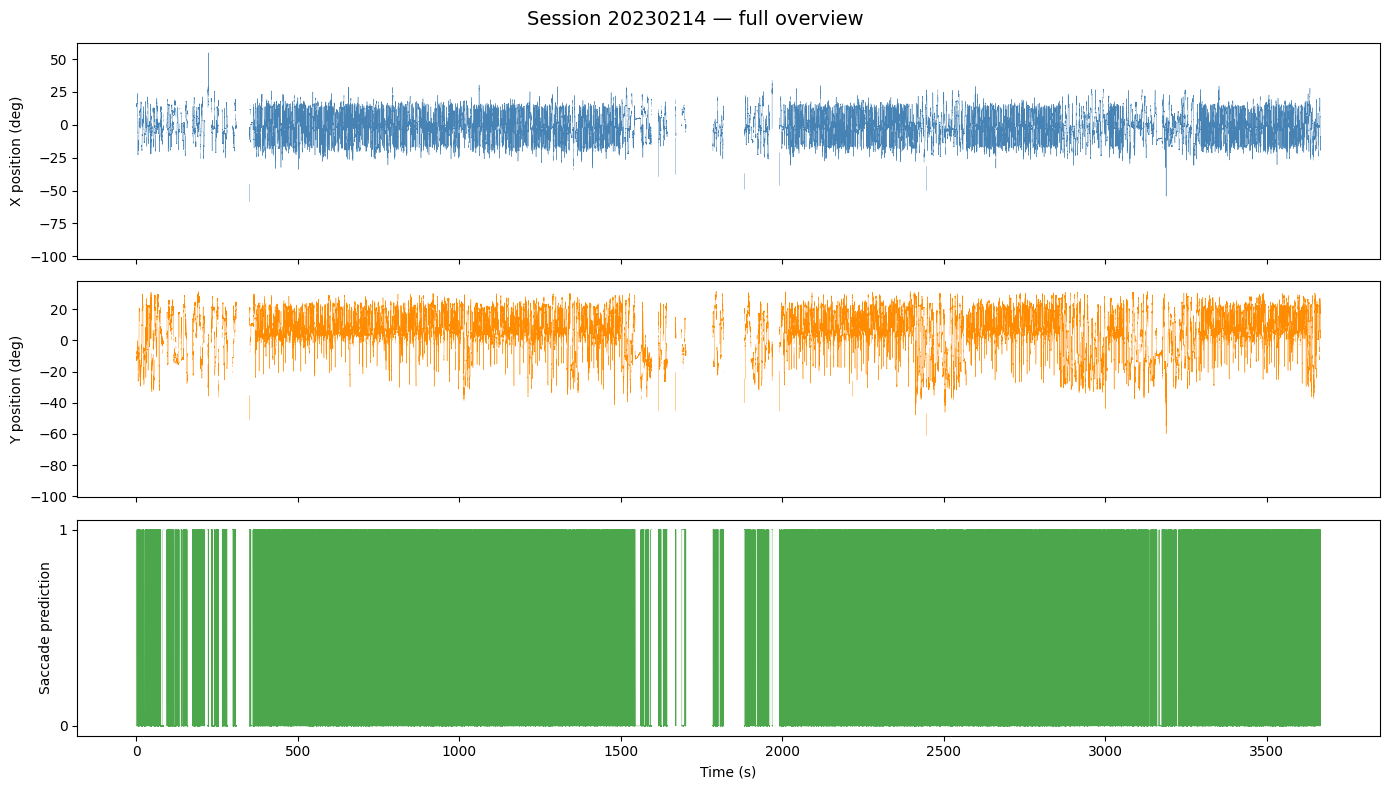

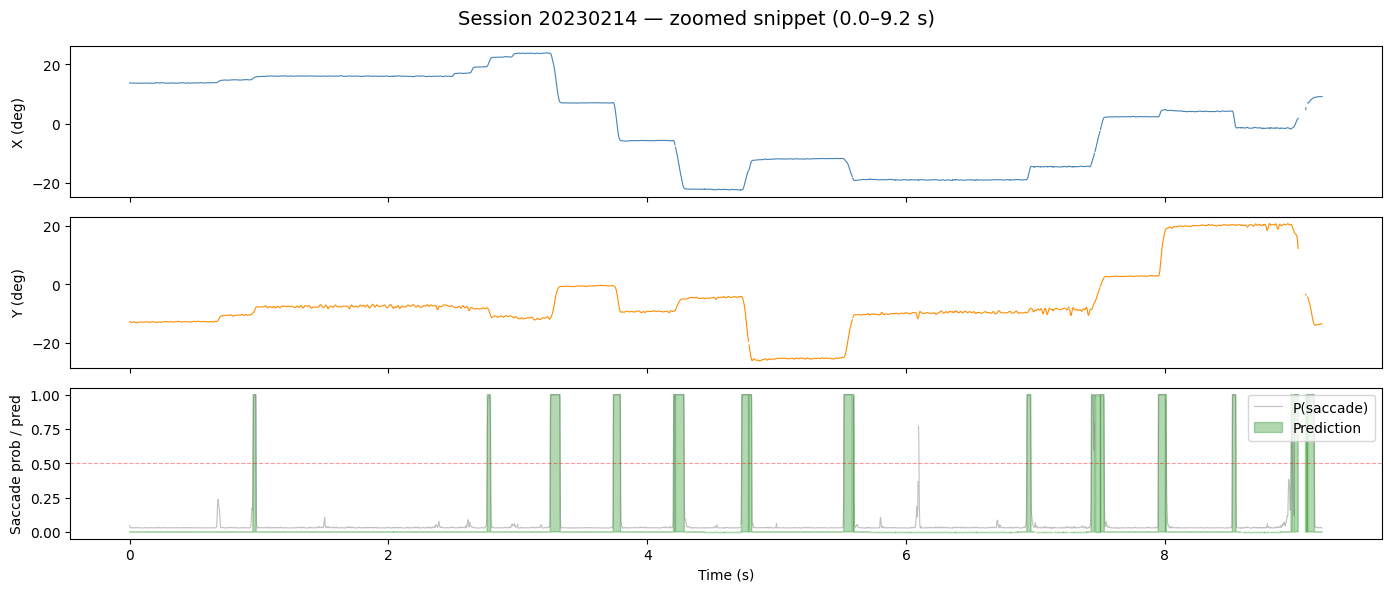

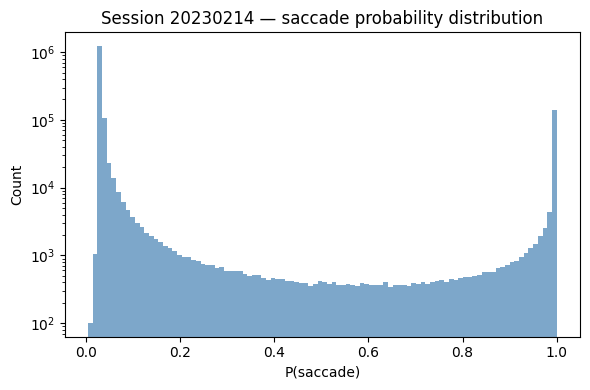

Session 20230214: 3668.9s, 10615 saccades detected, 12.7% NaN


In [4]:
########################################
# CHANGE THIS to pick a session
########################################
session = "20230214"
########################################

s = stitched[session]
x = s["x_nan"]
y = s["y_nan"]
pred = s["pred_nan"]
prob = s["prob_sacc_nan"]
time = np.arange(len(x)) / fs

# --- Plot 1: Full session overview ---
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle(f"Session {session} — full overview", fontsize=14)

axes[0].plot(time, x, lw=0.3, color="steelblue")
axes[0].set_ylabel("X position (deg)")

axes[1].plot(time, y, lw=0.3, color="darkorange")
axes[1].set_ylabel("Y position (deg)")

axes[2].plot(time, pred, lw=0.3, color="green", alpha=0.7)
axes[2].set_ylabel("Saccade prediction")
axes[2].set_xlabel("Time (s)")
axes[2].set_yticks([0, 1])

plt.tight_layout()
plt.show()

# --- Plot 2: Zoomed 10-second snippet around first detected saccade ---
sacc_idx = np.where(np.diff(np.nan_to_num(pred)) == 1)[0]
if len(sacc_idx) > 5:
    center = sacc_idx[5]
else:
    center = len(x) // 2

t_start = max(0, center - 5 * fs)
t_end = min(len(x), center + 5 * fs)
sl = slice(int(t_start), int(t_end))

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f"Session {session} — zoomed snippet ({time[int(t_start)]:.1f}–{time[int(t_end)-1]:.1f} s)", fontsize=14)

axes[0].plot(time[sl], x[sl], lw=0.8, color="steelblue")
axes[0].set_ylabel("X (deg)")

axes[1].plot(time[sl], y[sl], lw=0.8, color="darkorange")
axes[1].set_ylabel("Y (deg)")

axes[2].plot(time[sl], prob[sl], lw=0.8, color="gray", alpha=0.5, label="P(saccade)")
axes[2].fill_between(time[sl], 0, pred[sl], color="green", alpha=0.3, label="Prediction")
axes[2].axhline(0.5, ls="--", color="red", alpha=0.4, lw=0.8)
axes[2].set_ylabel("Saccade prob / pred")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

# --- Plot 3: Probability distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
valid_prob = prob[~np.isnan(prob)]
ax.hist(valid_prob, bins=100, color="steelblue", edgecolor="none", alpha=0.7)
ax.set_xlabel("P(saccade)")
ax.set_ylabel("Count")
ax.set_title(f"Session {session} — saccade probability distribution")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# --- Summary stats ---
n_sacc = len(sacc_idx)
dur_s = len(x) / fs
pct_nan = np.isnan(x).mean() * 100
print(f"Session {session}: {dur_s:.1f}s, {n_sacc} saccades detected, {pct_nan:.1f}% NaN")

Interactive viewer -- Use the dropdown to pick a session and the slider to scrub through 20-second windows.

In [6]:
import ipywidgets as widgets
from IPython.display import display

DS = 5  # downsample: plot every 5th point for speed

session_names = list(stitched.keys())

session_dropdown = widgets.Dropdown(options=session_names, value=session_names[0], description="Session:")
time_slider = widgets.FloatSlider(
    value=0, min=0, max=1, step=1,
    description="Start (s):", layout=widgets.Layout(width="80%"),
    continuous_update=False
)
out = widgets.Output()

def update_slider_range(*args):
    sess = session_dropdown.value
    sess_dur = len(stitched[sess]["x_nan"]) / fs
    time_slider.max = max(0, sess_dur - 20)
    if time_slider.value > time_slider.max:
        time_slider.value = 0

session_dropdown.observe(update_slider_range, names="value")
update_slider_range()

def plot_window(session, t_start_s):
    out.clear_output(wait=True)
    with out:
        s = stitched[session]
        x = s["x_nan"]
        y = s["y_nan"]
        pred = s["pred_nan"]
        prob = s["prob_sacc_nan"]

        i0 = int(t_start_s * fs)
        i1 = min(len(x), i0 + 20 * fs)
        sl = slice(i0, i1, DS)
        t = np.arange(i0, i1, DS) / fs

        fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)
        fig.suptitle(f"Session {session} — {t_start_s:.1f} to {t_start_s + 20:.1f} s", fontsize=14)

        axes[0].plot(t, x[sl], lw=0.8, color="steelblue")
        axes[0].set_ylabel("X (deg)")

        axes[1].plot(t, y[sl], lw=0.8, color="darkorange")
        axes[1].set_ylabel("Y (deg)")

        axes[2].plot(t, prob[sl], lw=0.8, color="gray", alpha=0.5, label="P(saccade)")
        axes[2].fill_between(t, 0, pred[sl], color="green", alpha=0.3, label="Prediction")
        axes[2].axhline(0.5, ls="--", color="red", alpha=0.4, lw=0.8)
        axes[2].set_ylabel("Saccade prob / pred")
        axes[2].set_xlabel("Time (s)")
        axes[2].legend(loc="upper right")

        plt.tight_layout()
        plt.show()

interactive = widgets.interactive_output(plot_window, {"session": session_dropdown, "t_start_s": time_slider})
display(widgets.VBox([session_dropdown, time_slider, out]))
plot_window(session_dropdown.value, time_slider.value)

## Saccade amplitude distribution (micro- vs. macro-saccades)

UnEye only labels saccade / no-saccade. To find **microsaccades** we measure each
detected event's amplitude from the eye-position trace and look at the distribution.

- Events are read from the binary `pred` mask (onset = 0→1, offset = 1→0).
- Amplitude = eye displacement from onset to offset sample, computed on the
  interpolated `x_orig`/`y_orig` (in degrees): `sqrt(dx^2 + dy^2)`.
- Events overlapping reinserted NaNs, or shorter than `min_dur_ms`, are dropped.
- Convention: **amplitude < 1°** = microsaccade (dashed line on the histogram).
- The amplitude-vs-peak-velocity ("main sequence") plot confirms small events are
  genuine saccades rather than noise.


56152 saccades kept (>= 6 ms, no NaN overlap)
1064 below 1.0deg  (1.9% microsaccades)
median amp = 14.58deg, 5th pct = 2.29deg


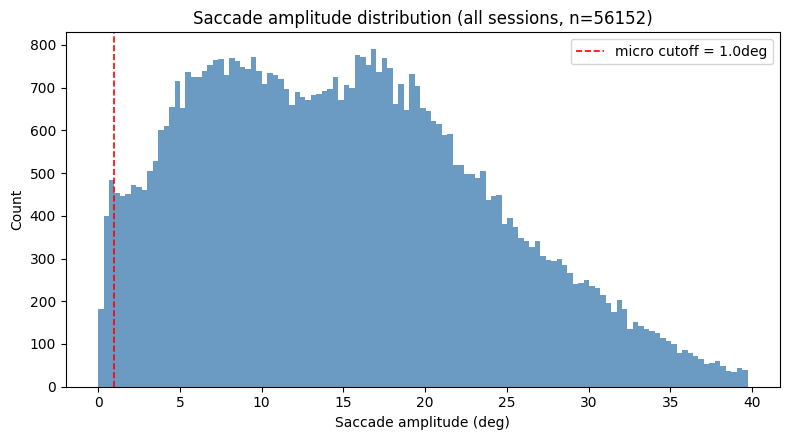

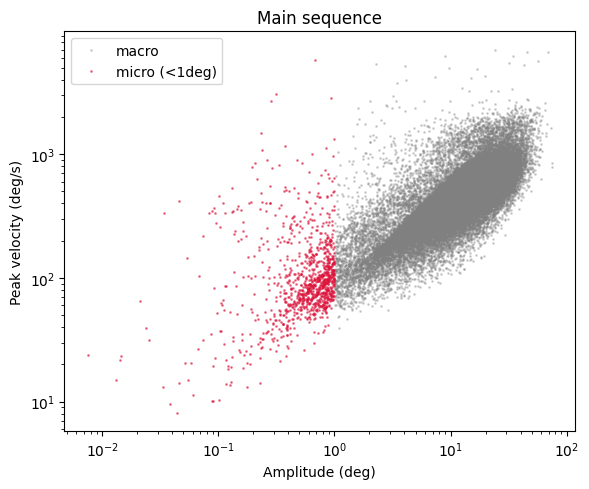

In [7]:
# ---------------------------------------------------------------
# Build a per-saccade table (all sessions) and plot amplitude dist.
# ---------------------------------------------------------------
min_dur_ms   = 6      # drop events shorter than this (likely noise)
micro_thresh = 1.0    # deg; amplitude below this = microsaccade

min_dur_samp = int(round(min_dur_ms / 1000 * fs))

events = []
for sess, s in stitched.items():
    pred = np.nan_to_num(s["pred_orig"]).astype(int)   # binary mask, no NaNs
    x    = s["x_orig"]                                  # interpolated, in deg
    y    = s["y_orig"]
    nan_mask = s["nan_mask"]

    d = np.diff(pred)
    onsets  = np.where(d == 1)[0] + 1
    offsets = np.where(d == -1)[0] + 1

    # align edges (handle mask starting/ending inside a saccade)
    if offsets.size and (onsets.size == 0 or offsets[0] < onsets[0]):
        offsets = offsets[1:]
    if onsets.size and (offsets.size == 0 or onsets[-1] > offsets[-1]):
        onsets = onsets[:-1]
    n = min(len(onsets), len(offsets))
    onsets, offsets = onsets[:n], offsets[:n]

    for on, off in zip(onsets, offsets):
        dur = off - on
        if dur < min_dur_samp:
            continue
        # skip events touching originally-missing data
        if nan_mask[on:off].any():
            continue

        dx = x[off] - x[on]
        dy = y[off] - y[on]
        amp = np.hypot(dx, dy)

        # peak velocity (deg/s) within the event, for the main-sequence check
        seg_x, seg_y = x[on:off + 1], y[on:off + 1]
        vx = np.diff(seg_x) * fs
        vy = np.diff(seg_y) * fs
        vpeak = np.nanmax(np.hypot(vx, vy)) if len(vx) else np.nan

        events.append({
            "session": sess, "onset": on, "offset": off,
            "dur_ms": dur / fs * 1000, "amp_deg": amp, "vpeak_dps": vpeak,
        })

sacc = pd.DataFrame(events)
sacc["is_micro"] = sacc["amp_deg"] < micro_thresh

n_total = len(sacc)
n_micro = int(sacc["is_micro"].sum())
print(f"{n_total} saccades kept (>= {min_dur_ms} ms, no NaN overlap)")
print(f"{n_micro} below {micro_thresh}deg  ({100*n_micro/n_total:.1f}% microsaccades)")
print(f"median amp = {sacc['amp_deg'].median():.2f}deg, "
      f"5th pct = {sacc['amp_deg'].quantile(0.05):.2f}deg")

# ---- Plot 1: amplitude distribution ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sacc["amp_deg"], bins=np.linspace(0, max(5, sacc["amp_deg"].quantile(0.99)), 120),
        color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(micro_thresh, ls="--", color="red", lw=1.2,
           label=f"micro cutoff = {micro_thresh}deg")
ax.set_xlabel("Saccade amplitude (deg)")
ax.set_ylabel("Count")
ax.set_title(f"Saccade amplitude distribution (all sessions, n={n_total})")
ax.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: main sequence (amplitude vs peak velocity, log-log) ----
fig, ax = plt.subplots(figsize=(6, 5))
m = sacc["is_micro"]
ax.loglog(sacc.loc[~m, "amp_deg"], sacc.loc[~m, "vpeak_dps"], ".",
          ms=2, alpha=0.3, color="gray", label="macro")
ax.loglog(sacc.loc[m, "amp_deg"], sacc.loc[m, "vpeak_dps"], ".",
          ms=2, alpha=0.5, color="crimson", label="micro (<1deg)")
ax.set_xlabel("Amplitude (deg)")
ax.set_ylabel("Peak velocity (deg/s)")
ax.set_title("Main sequence")
ax.legend()
plt.tight_layout()
plt.show()


## Saccade duration & inter-saccade interval

Both derived from the same per-saccade table `sacc` built above.
- **Duration** = `dur_ms` (offset - onset, in ms).
- **Inter-saccade interval (ISI)** = gap between consecutive saccade onsets,
  computed **within each session** (`groupby("session")`) so it never spans the
  stitch boundary between sessions. Shown as onset-to-onset time.


duration: median = 48.0 ms, 95th pct = 88.0 ms, n = 56152


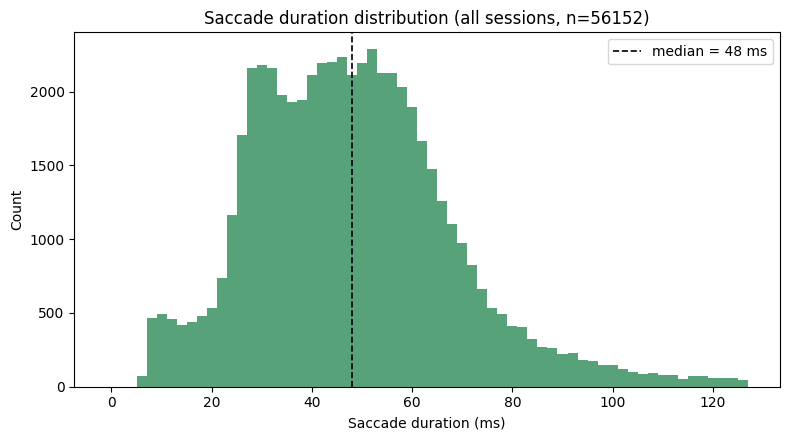

In [10]:
# ---- Saccade duration distribution ----
dur = sacc["dur_ms"].to_numpy()
print(f"duration: median = {np.median(dur):.1f} ms, "
      f"95th pct = {np.percentile(dur, 95):.1f} ms, n = {len(dur)}")

# bins aligned to the sampling step (1000/fs ms) so the discrete sample-quantized
# durations don't produce empty "comb" bins.
step = 1000.0 / fs                                  # 2 ms at 500 Hz
edges = np.arange(0, np.percentile(dur, 99) + step, step) - step / 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(dur, bins=edges, color="seagreen", edgecolor="none", alpha=0.8)
ax.axvline(np.median(dur), ls="--", color="black", lw=1.2,
           label=f"median = {np.median(dur):.0f} ms")
ax.set_xlabel("Saccade duration (ms)")
ax.set_ylabel("Count")
ax.set_title(f"Saccade duration distribution (all sessions, n={len(dur)})")
ax.legend()
plt.tight_layout()
plt.show()


ISI: median = 0.408 s, 95th pct = 1.622 s, n = 56143


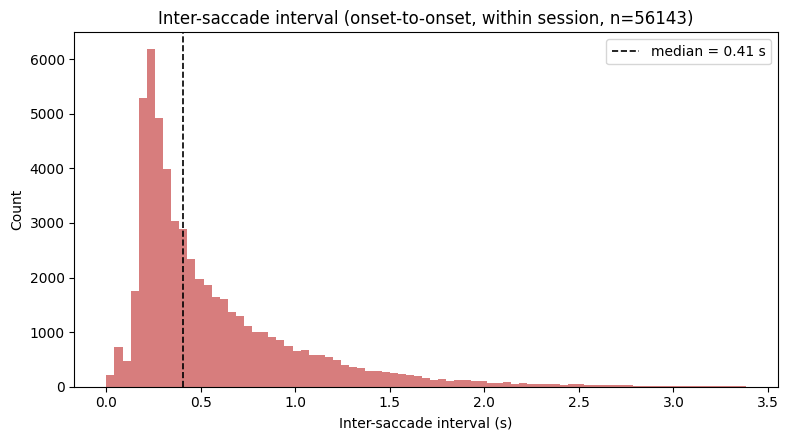

In [9]:
# ---- Inter-saccade interval (onset-to-onset, within session) ----
# diff of onsets per session so intervals never cross the stitch boundary.
isi_s = []
for sess, g in sacc.groupby("session"):
    onsets = np.sort(g["onset"].to_numpy())
    if len(onsets) > 1:
        isi_s.append(np.diff(onsets) / fs)          # samples -> seconds
isi_s = np.concatenate(isi_s) if isi_s else np.array([])

print(f"ISI: median = {np.median(isi_s):.3f} s, "
      f"95th pct = {np.percentile(isi_s, 95):.3f} s, n = {len(isi_s)}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(isi_s, bins=np.linspace(0, np.percentile(isi_s, 99), 80),
        color="indianred", edgecolor="none", alpha=0.8)
ax.axvline(np.median(isi_s), ls="--", color="black", lw=1.2,
           label=f"median = {np.median(isi_s):.2f} s")
ax.set_xlabel("Inter-saccade interval (s)")
ax.set_ylabel("Count")
ax.set_title(f"Inter-saccade interval (onset-to-onset, within session, n={len(isi_s)})")
ax.legend()
plt.tight_layout()
plt.show()
